# 01 - Data download and cleaning

**Appliance energy forecasting**

This notebook covers the first stage of the pipeline: obtaining the raw
*Appliances Energy Prediction* dataset, checking its integrity, aggregating it from
10-minute resolution to hourly resolution, and saving a clean, analysis-ready
dataset for the notebooks that follow.

**Outputs produced**

```text
data/interim/appliance_10min.csv
data/processed/appliance_hourly.csv
outputs/figures/01_raw_series_10min.png
outputs/figures/01_raw_week_10min.png
outputs/figures/01_hourly_vs_10min.png
```

## 1. Imports and configuration

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# 2. Configuration

# The notebooks live in <project_root>/notebooks, so the project root is one
# level up when the notebook is launched from its own directory.
def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

TARGET = "Appliances"

RAW_FILE = RAW_DIR / "energydata_complete.csv"
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00374/energydata_complete.csv"
)

# Sampling information
RAW_FREQ = "10min"
HOURLY_FREQ = "h"
OBS_PER_HOUR = 6

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [3]:
# 3. Small helpers used throughout the notebook

def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


def describe_index(index, expected_freq):
    """Summarise a DatetimeIndex: coverage, ordering, duplicates and gaps."""

    full_range = pd.date_range(
        start=index.min(),
        end=index.max(),
        freq=expected_freq,
    )

    summary = {
        "start": index.min(),
        "end": index.max(),
        "n_observations": len(index),
        "n_expected": len(full_range),
        "n_missing_timestamps": len(full_range.difference(index)),
        "n_duplicate_timestamps": int(index.duplicated().sum()),
        "is_monotonic_increasing": bool(index.is_monotonic_increasing),
    }

    return pd.Series(summary), full_range

## 2. Load the raw data

The dataset is the UCI *Appliances Energy Prediction* dataset (Candanedo, Feldheim and
Deramaix, 2017). It records energy use of appliances and lights in a low-energy house in
Stambruges, Belgium, every 10 minutes over roughly 4.5 months, together with indoor
temperature/humidity from a ZigBee wireless sensor network and outdoor weather from the
nearest airport weather station (Chièvres).

The loader below reads the cached copy in `data/raw/` if it exists and otherwise
downloads it once and caches it, so that the notebook is reproducible from a fresh clone
without committing the raw data to the repository.

In [4]:
# 4. Load raw data

def load_raw_data(raw_file=RAW_FILE, url=DATA_URL):
    """
    Load the raw 10-minute dataset.

    The file is read from data/raw if it is already present; otherwise it is
    downloaded from the UCI repository and cached there.
    """

    if raw_file.exists():
        print("Reading cached raw file:", raw_file)
    else:
        print("Raw file not found locally. Downloading from UCI ...")

        downloaded = pd.read_csv(url)
        downloaded.to_csv(raw_file, index=False)

        print("Cached raw file to:", raw_file)

    return pd.read_csv(raw_file)


raw = load_raw_data()

print("\nRaw shape:", raw.shape)

raw.head()

Reading cached raw file: C:\Users\cjfin\Desktop\assignment 2\data\raw\energydata_complete.csv

Raw shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [5]:
# 5. Column inventory

INDOOR_TEMP_COLS = [f"T{i}" for i in range(1, 10)]
INDOOR_HUM_COLS = [f"RH_{i}" for i in range(1, 10)]

OUTDOOR_COLS = [
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint",
]

RANDOM_COLS = ["rv1", "rv2"]

print("Columns:", raw.columns.tolist())
print("\nIndoor temperature :", INDOOR_TEMP_COLS)
print("Indoor humidity    :", INDOOR_HUM_COLS)
print("Outdoor weather    :", OUTDOOR_COLS)
print("Random noise cols  :", RANDOM_COLS)

raw.dtypes.to_frame("dtype").T

Columns: ['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

Indoor temperature : ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Indoor humidity    : ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']
Outdoor weather    : ['T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
Random noise cols  : ['rv1', 'rv2']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
dtype,object,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


Two points worth recording before any cleaning:

* `rv1` and `rv2` are **random variables** deliberately added by the dataset authors as
  a filter-method benchmark for feature selection. They carry no information about
  appliance use and are dropped here so that they cannot leak into any later feature
  set.
* `T6` and `RH_6` are recorded **outside** the building (north façade), not indoors,
  despite following the indoor naming convention. They are therefore closer in character
  to the weather variables and are treated as such in the exploratory notebook.

## 3. Timestamp parsing and index integrity

The `date` column is parsed to a `datetime64` type and set as the index. Three
properties are checked, because all later modelling assumes a regular, gap-free series:

1. the index is strictly increasing,
2. no timestamp is duplicated,
3. no timestamp is missing from the expected 10-minute grid.

In [6]:
# 6. Parse timestamps and set the index

def prepare_index(df, date_col="date"):
    """Parse the timestamp column, set it as the index and sort chronologically."""

    out = df.copy()

    out[date_col] = pd.to_datetime(out[date_col])
    out = out.set_index(date_col).sort_index()

    # Every remaining column should be numeric; coerce defensively.
    for col in out.columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    return out


data_10min = prepare_index(raw)

index_summary, expected_range = describe_index(data_10min.index, RAW_FREQ)

index_summary.to_frame("value")

,value
start,2016-01-11 17:00:00
end,2016-05-27 18:00:00
n_observations,19735
n_expected,19735
n_missing_timestamps,0
n_duplicate_timestamps,0
is_monotonic_increasing,True


In [7]:
# 7. Explicitly report any gaps or duplicates

missing_timestamps = expected_range.difference(data_10min.index)

print("Missing timestamps on the 10-minute grid:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print(missing_timestamps[:20])

print("\nObserved spacing between consecutive observations:")
print(data_10min.index.to_series().diff().value_counts().head())

print("\nTotal span:", data_10min.index.max() - data_10min.index.min())

Missing timestamps on the 10-minute grid: 0

Observed spacing between consecutive observations:
date
0 days 00:10:00    19734
Name: count, dtype: int64

Total span: 137 days 01:00:00


## 4. Missing values and target plausibility

Missing values are checked per column. The target, `Appliances`, is measured in Wh
per 10-minute interval and should be non-negative; `lights` is expected to be zero for
most of the record.

In [8]:
# 8. Missing value audit

missing = pd.DataFrame({
    "n_missing": data_10min.isna().sum(),
    "pct_missing": 100 * data_10min.isna().mean(),
})

print("Columns with at least one missing value:")
print(missing[missing["n_missing"] > 0])

print("\nTotal missing cells:", int(data_10min.isna().sum().sum()))

missing.T

Columns with at least one missing value:
Empty DataFrame
Columns: [n_missing, pct_missing]
Index: []

Total missing cells: 0


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
n_missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct_missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# 9. Target sanity checks

y_raw = data_10min[TARGET]

checks = {
    "n_observations": len(y_raw),
    "n_missing": int(y_raw.isna().sum()),
    "n_negative": int((y_raw < 0).sum()),
    "n_zero": int((y_raw == 0).sum()),
    "min": y_raw.min(),
    "median": y_raw.median(),
    "mean": y_raw.mean(),
    "max": y_raw.max(),
    "std": y_raw.std(),
    "skew": y_raw.skew(),
}

print(pd.Series(checks).to_string())

print("\nProportion of intervals with lights == 0:", round(float((data_10min["lights"] == 0).mean()), 3))

y_raw.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(TARGET).T

n_observations    19735.000000
n_missing             0.000000
n_negative            0.000000
n_zero                0.000000
min                  10.000000
median               60.000000
mean                 97.694958
max                1080.000000
std                 102.524891
skew                  3.386367

Proportion of intervals with lights == 0: 0.773


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Appliances,19735.0,97.694958,102.524891,10.0,30.0,50.0,60.0,100.0,330.0,576.6,1080.0


## 5. Initial plots of the raw 10-minute series

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\01_raw_series_10min.png


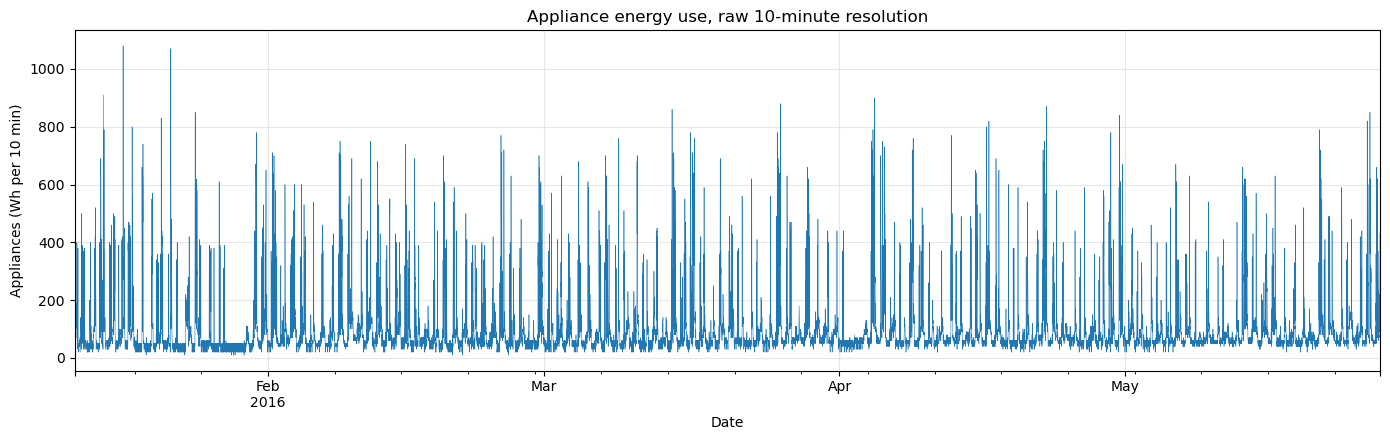

In [10]:
# 10. Full raw series

fig, ax = plt.subplots(figsize=(14, 4.5))

y_raw.plot(ax=ax, linewidth=0.4, color="tab:blue")

ax.set_title("Appliance energy use, raw 10-minute resolution")
ax.set_ylabel("Appliances (Wh per 10 min)")
ax.set_xlabel("Date")

fig.tight_layout()
save_fig(fig, "01_raw_series_10min.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\01_raw_week_10min.png


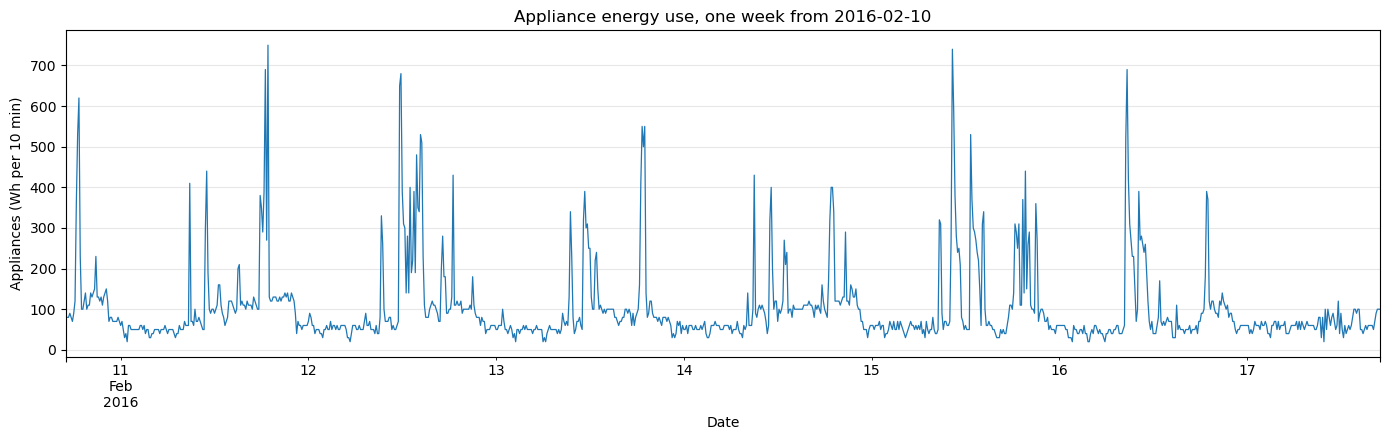

In [11]:
# 11. One-week window, to expose the within-day structure

week_start = y_raw.index.min() + pd.Timedelta(days=30)
week_end = week_start + pd.Timedelta(days=7)

fig, ax = plt.subplots(figsize=(14, 4.5))

y_raw.loc[week_start:week_end].plot(ax=ax, linewidth=0.9, color="tab:blue")

ax.set_title(f"Appliance energy use, one week from {week_start.date()}")
ax.set_ylabel("Appliances (Wh per 10 min)")
ax.set_xlabel("Date")

fig.tight_layout()
save_fig(fig, "01_raw_week_10min.png")

plt.show()

## 6. Resample to hourly resolution

The 10-minute series is aggregated to hourly means. The mean is used rather than the
sum so that all variables (energy, temperature, humidity) are treated consistently; the
hourly mean of the 10-minute energy readings is proportional to the hourly total, so
forecast accuracy comparisons are unaffected.

Note: the first and last hours of the record may be *partial*. An hour
containing fewer than six 10-minute readings would be averaged over fewer observations
and is not comparable with the rest of the series, so incomplete hours are identified and
dropped rather than silently averaged.

In [12]:
# 12. Identify incomplete hours before aggregating

obs_per_hour = data_10min[TARGET].resample(HOURLY_FREQ).count()

print("Distribution of observations per hour:")
print(obs_per_hour.value_counts().to_string())

incomplete_hours = obs_per_hour[obs_per_hour < OBS_PER_HOUR]

print("\nIncomplete hours:", len(incomplete_hours))
print(incomplete_hours.to_string())

Distribution of observations per hour:
Appliances
6    3289
1       1

Incomplete hours: 1
date
2016-05-27 18:00:00    1
Freq: h


In [13]:
# 13. Resample to hourly means

def to_hourly(df, target=TARGET, freq=HOURLY_FREQ, obs_per_hour=OBS_PER_HOUR):
    """
    Aggregate the 10-minute data to hourly means.

    Hours containing fewer than `obs_per_hour` raw observations are dropped,
    because a partial hour is not comparable with a complete one. Any remaining
    gap on the hourly grid is filled by time interpolation so that the series has
    a strict hourly frequency.
    """

    counts = df[target].resample(freq).count()
    complete_hours = counts[counts == obs_per_hour].index

    hourly = df.resample(freq).mean()
    hourly = hourly.loc[hourly.index.isin(complete_hours)]

    # Enforce a regular hourly grid and interpolate any interior gap.
    full_range = pd.date_range(hourly.index.min(), hourly.index.max(), freq=freq)

    n_interior_gaps = len(full_range.difference(hourly.index))

    hourly = hourly.reindex(full_range)
    hourly = hourly.interpolate("time").dropna()
    hourly.index.name = df.index.name

    print("Hours dropped as incomplete:", len(counts) - len(complete_hours))
    print("Interior hourly gaps interpolated:", n_interior_gaps)

    return hourly


hourly = to_hourly(data_10min.drop(columns=RANDOM_COLS))

print("\nHourly shape:", hourly.shape)

hourly.head()

Hours dropped as incomplete: 1
Interior hourly gaps interpolated: 0

Hourly shape: (3289, 26)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667


In [14]:
# 14. Verify the hourly series

hourly_summary, _ = describe_index(hourly.index, HOURLY_FREQ)

print(hourly_summary.to_string())

print("\nMissing cells after resampling:", int(hourly.isna().sum().sum()))
print("Inferred frequency:", pd.infer_freq(hourly.index))

hourly[TARGET].describe().to_frame(TARGET).T

start                      2016-01-11 17:00:00
end                        2016-05-27 17:00:00
n_observations                            3289
n_expected                                3289
n_missing_timestamps                         0
n_duplicate_timestamps                       0
is_monotonic_increasing                   True

Missing cells after resampling: 0
Inferred frequency: h


,count,mean,std,min,25%,50%,75%,max
Appliances,3289.0,97.678119,81.019086,28.333333,50.0,63.333333,110.0,608.333333


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\01_hourly_vs_10min.png


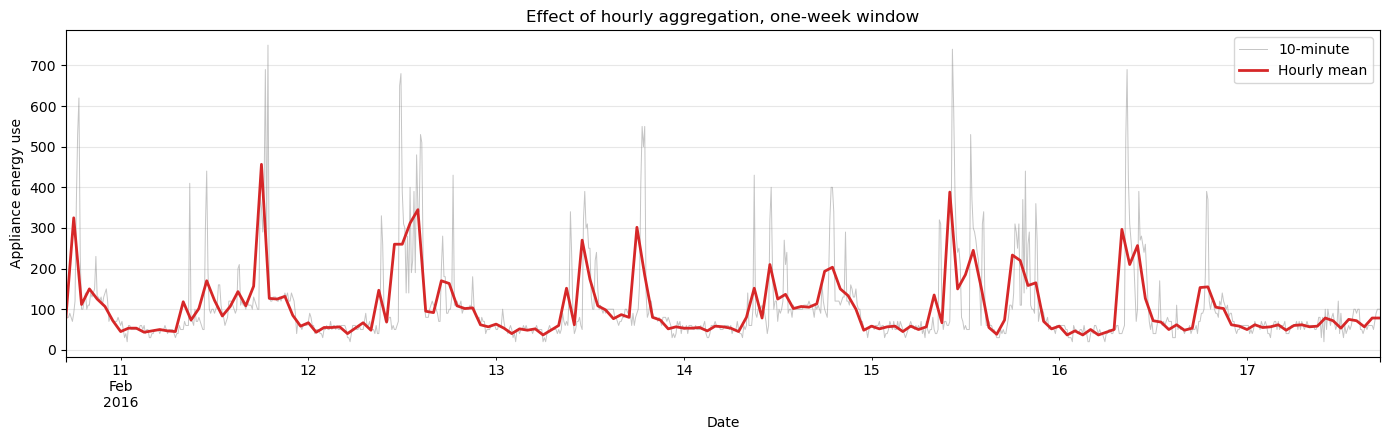

In [15]:
# 15. Compare the raw and hourly series over the same window

fig, ax = plt.subplots(figsize=(14, 4.5))

y_raw.loc[week_start:week_end].plot(
    ax=ax,
    linewidth=0.7,
    alpha=0.45,
    color="tab:grey",
    label="10-minute",
)

hourly.loc[week_start:week_end, TARGET].plot(
    ax=ax,
    linewidth=2.0,
    color="tab:red",
    label="Hourly mean",
)

ax.set_title("Effect of hourly aggregation, one-week window")
ax.set_ylabel("Appliance energy use")
ax.set_xlabel("Date")
ax.legend()

fig.tight_layout()
save_fig(fig, "01_hourly_vs_10min.png")

plt.show()

## 7. Train/test split preview

In [16]:
# 16. Confirm the intended split is feasible

TEST_STEPS = 14 * 24    # final 14 days, hourly
HORIZON = 24            # 24-hour forecast horizon

split_point = len(hourly) - TEST_STEPS

train_index = hourly.index[:split_point]
test_index = hourly.index[split_point:]

print("Total hourly observations:", len(hourly))
print("Training observations    :", len(train_index))
print("Test observations        :", len(test_index))
print()
print("Train period:", train_index.min(), "to", train_index.max())
print("Test period :", test_index.min(), "to", test_index.max())
print()
print("Training weeks available:", round(len(train_index) / (24 * 7), 1))

Total hourly observations: 3289
Training observations    : 2953
Test observations        : 336

Train period: 2016-01-11 17:00:00 to 2016-05-13 17:00:00
Test period : 2016-05-13 18:00:00 to 2016-05-27 17:00:00

Training weeks available: 17.6


## 8. Save cleaned datasets

In [17]:
# 17. Save interim and processed datasets

interim_path = INTERIM_DIR / "appliance_10min.csv"
processed_path = PROCESSED_DIR / "appliance_hourly.csv"

data_10min.drop(columns=RANDOM_COLS).to_csv(interim_path)
hourly.to_csv(processed_path)

print("Saved:", interim_path)
print("Saved:", processed_path)

Saved: C:\Users\cjfin\Desktop\assignment 2\data\interim\appliance_10min.csv
Saved: C:\Users\cjfin\Desktop\assignment 2\data\processed\appliance_hourly.csv


In [18]:
# 18. Reload the processed file to confirm it round-trips correctly

check = pd.read_csv(processed_path, index_col=0, parse_dates=True)
check = check.asfreq(HOURLY_FREQ)

assert check.shape == hourly.shape, "Shape changed on reload"
assert check[TARGET].isna().sum() == 0, "Missing target values after reload"
assert check.index.is_monotonic_increasing, "Index not sorted"
assert pd.infer_freq(check.index) == "h", "Index is not strictly hourly"

print("Reload checks passed.")
print("Shape:", check.shape)
print("Range:", check.index.min(), "to", check.index.max())

check.head(3)

Reload checks passed.
Shape: (3289, 26)
Range: 2016-01-11 17:00:00 to 2016-05-27 17:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667
